In [12]:
from loguru import logger
from collections import defaultdict


from behave_analysis.utils.rayleigh.load_rayleigh import extract_rayleigh_path, load_rayleigh_data
from behave_analysis.utils.rayleigh.manipulate_rayleigh_df import extract_compartment_values
from behave_analysis.analyze.classification.head_direction import angle_similarity, rayleigh_threshold, check_both_compartments_significant
from behave_analysis.process.session import get_experiment
from behave_analysis.utils.rayleigh.load_rayleigh import collect_all_rayleigh_paths, load_all_rayleigh_data
from behave_analysis.utils.rayleigh.manipulate_rayleigh_df import extract_firing_rates

from settings.settings_analyze_efizz import Settings_ae as settings

import matplotlib.pyplot as plt


In [2]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import (
    JAL7_sesh8_9apr,
    JAL7_sesh9_16apr,
    JAL7_flip5_22mar,
    JAL7_flip2_12mar,
    JAL7_23apr,
    JAL7_30apr,
)
from behave_analysis.database.Experiments.JAL008_ex import (
    JAL8_flip1_25apr,
    JAL8_flip2_29apr,
    JAL8_tiny_3may,
    JAL8_flip4_10may,
    JAL8_14may,
    JAL8_21may,
    JAL8_flip3_7may,
)

# The values must be in order of data for the code to work
mice_groups = {
    "JAL6": ["JAL6_flip3_18mar", "JAL6_flip4_21mar", "JAL6_flip5_25mar", "JAL6_28mar"],
    "JAL3": ["JAL3_25aug", "JAL3_1sept", "JAL3_4sept", "JAL3_7sept"],
    "JAL7": ["JAL7_flip2_12mar", "JAL7_flip5_22mar", "JAL7_sesh8_9apr", "JAL7_sesh9_16apr", "JAL7_23apr"],
    "JAL8": ["JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip4_10may", "JAL8_flip3_7may", "JAL8_14may"],
    "JAL4": ["JAL4_28aug", "JAL4_3rdSept", "JAL4_11thSept", "JAL4_19thSept"],
    "JAL5": ["JAL5_8thSept", "JAL5_21stSept"],
}

# The experiment objects index must match the session name index for the code to work
experiments_objects = [
    JAL6_flip3_18mar,
    JAL6_flip4_21mar,
    JAL6_flip5_25mar,
    JAL6_28mar,
    JAL3_25aug,
    JAL3_1sept,
    JAL3_4sept,
    JAL3_7sept,
    JAL005_8thSept,
    JAL005_21stSept,
    JAL7_sesh8_9apr,
    JAL7_sesh9_16apr,
    JAL7_flip5_22mar,
    JAL7_flip2_12mar,
    JAL7_23apr,
    JAL8_flip1_25apr,
    JAL8_flip2_29apr,
    JAL8_flip4_10may,
    JAL8_14may,
    JAL8_flip3_7may,
    JAL4_3rdSept,
    JAL4_19thSept,
    JAL4_28aug,
    JAL4_11thSept,
]

# The session name indexes must match the experiment object indexes
session_names = [
    "JAL6_flip3_18mar",
    "JAL6_flip4_21mar",
    "JAL6_flip5_25mar",
    "JAL6_28mar",
    "JAL3_25aug",
    "JAL3_1sept",
    "JAL3_4sept",
    "JAL3_7sept",
    "JAL5_8thSept",
    "JAL5_21stSept",
    "JAL7_sesh8_9apr",
    "JAL7_sesh9_16apr",
    "JAL7_flip5_22mar",
    "JAL7_flip2_12mar",
    "JAL7_23apr",
    "JAL8_flip1_25apr",
    "JAL8_flip2_29apr",
    "JAL8_flip4_10may",
    "JAL8_14may",
    "JAL8_flip3_7may",
    "JAL4_3rdSept",
    "JAL4_19thSept",
    "JAL4_28aug",
    "JAL4_11thSept",
]

In [3]:
angle_keys = ['hdir_Rayleigh.arrow', 'hsa_Rayleigh.arrow', 'h_postflipbar_a_Rayleigh.arrow', 'h_preflipbar_a_Rayleigh.arrow']
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]

# Get shelter cells

In [4]:
from collections import defaultdict
shelter_cells = defaultdict(lambda: defaultdict(list))


for i, session in enumerate(experiments_objects):
    loaded_session = get_experiment(session)
    paths = collect_all_rayleigh_paths(session=loaded_session, cluster_type="good", conditions=conditions)
    condition_data = load_all_rayleigh_data(paths)

    # Shelter-only condition
    shelter_only = condition_data["shelter_only"]
    nCells = len(shelter_only["hdir_Rayleigh.arrow"]["Rayleigh"])  # Ensure this matches cluster ID length

    for cell in range(nCells):
        cell_id = shelter_only["hdir_Rayleigh.arrow"]["clusterID"][cell]  # Get correct cluster ID
        
        largest_rayleigh = 0
        second_largest_rayleigh = 0  # Track second-largest value

        for angle_key in angle_keys:
            r = shelter_only[angle_key]["Rayleigh"][cell]
            for compartment in r:
                if compartment > largest_rayleigh:
                    second_largest_rayleigh = largest_rayleigh  # Update second largest before changing largest
                    largest_rayleigh = compartment
                elif compartment > second_largest_rayleigh:
                    second_largest_rayleigh = compartment  # Only update second largest if it's smaller than the largest

        # Get the Rayleigh value of interest (from hsa compartment)
        hsa_rayleigh_value = shelter_only["hsa_Rayleigh.arrow"]["Rayleigh"][cell][0]
        
        # Extract the max firing rate
        shelter_zone_firing_rates, threat_zone_firing_rates = extract_firing_rates(shelter_only["hsa_Rayleigh.arrow"], settings)
        max_fr_shelter_condition = max(shelter_zone_firing_rates[cell])

        # Criteria 1: Ensure the hsa Rayleigh value in the shelter conidtion shelter compartment is the largest AND strictly greater than the second-largest
        if hsa_rayleigh_value == largest_rayleigh and hsa_rayleigh_value > second_largest_rayleigh:
            # Criteria 2: The Rayleigh value of the hsa compartment is above 0.2
            if hsa_rayleigh_value > 0.2:
                # Criteria 3: the firing rate in the shelter zone is above 1 Hz
                if max_fr_shelter_condition > 1:
                    shelter_cells[session_names[i]]["Cell_ID"].append(cell_id)
                    shelter_cells[session_names[i]]["Cell_index"].append(cell_id)
    shelter_cells[session_names[i]]["total_cells"].append(nCells)
    logger.info(f"Session {session_names[i]}: {len(shelter_cells[session_names[i]]['Cell_ID'])} shelter cells found")
                    


2025-01-30 16:51:00.923 | INFO     | __main__:<module>:45 - Session JAL6_flip3_18mar: 12 shelter cells found
2025-01-30 16:51:01.723 | INFO     | __main__:<module>:45 - Session JAL6_flip4_21mar: 11 shelter cells found
2025-01-30 16:51:02.057 | INFO     | __main__:<module>:45 - Session JAL6_flip5_25mar: 4 shelter cells found
2025-01-30 16:51:02.455 | INFO     | __main__:<module>:45 - Session JAL6_28mar: 4 shelter cells found
2025-01-30 16:51:02.688 | INFO     | __main__:<module>:45 - Session JAL3_25aug: 1 shelter cells found
2025-01-30 16:51:02.927 | INFO     | __main__:<module>:45 - Session JAL3_1sept: 1 shelter cells found
2025-01-30 16:51:03.207 | INFO     | __main__:<module>:45 - Session JAL3_4sept: 1 shelter cells found
2025-01-30 16:51:03.563 | INFO     | __main__:<module>:45 - Session JAL3_7sept: 0 shelter cells found
2025-01-30 16:51:03.932 | INFO     | __main__:<module>:45 - Session JAL5_8thSept: 13 shelter cells found
2025-01-30 16:51:04.228 | INFO     | __main__:<module>:45 -

# Get pre flip barrier cells

In [5]:
pre_flip_barrier_cells = defaultdict(lambda: defaultdict(list))

for i, session in enumerate(experiments_objects):
    loaded_session = get_experiment(session)
    paths = collect_all_rayleigh_paths(session=loaded_session, cluster_type="good", conditions=conditions)
    condition_data = load_all_rayleigh_data(paths)
    pre_flip = condition_data["barrier_pre_flip"]
    nCells = len(pre_flip["hdir_Rayleigh.arrow"]["Rayleigh"])  # Ensure this matches cluster ID length

    for cell in range(nCells):
        cell_id = pre_flip["hdir_Rayleigh.arrow"]["clusterID"][cell]  # Get correct cluster ID, column doesnt matter
        largest_rayleigh = 0
        second_largest_rayleigh = 0  # Track second-largest value
        for angle_key in angle_keys:
            r = pre_flip[angle_key]["Rayleigh"][cell]
            for compartment in r:
                if compartment > largest_rayleigh:
                    second_largest_rayleigh = largest_rayleigh  # Update second largest before changing largest
                    largest_rayleigh = compartment
                elif compartment > second_largest_rayleigh:
                    second_largest_rayleigh = compartment  # Only update second largest if it's smaller than the largest

        # Get the Rayleigh value of interest (from preflip in threat compartment)
        pre_flip_rayleigh_value = pre_flip['h_preflipbar_a_Rayleigh.arrow']["Rayleigh"][cell][1]
        
        # Extract the max firing rate
        shelter_zone_firing_rates, threat_zone_firing_rates = extract_firing_rates(pre_flip['h_preflipbar_a_Rayleigh.arrow'], settings)
        max_fr = max(threat_zone_firing_rates[cell])

        # Criteria 1: Ensure the preflip Rayleigh value in the preflip conidtion threat compartment is the largest AND strictly greater than the second-largest
        if pre_flip_rayleigh_value == largest_rayleigh and pre_flip_rayleigh_value > second_largest_rayleigh:
            # Criteria 2: The Rayleigh value of the hsa compartment is above 0.2
            if pre_flip_rayleigh_value > 0.4:
                # Criteria 3: the firing rate in the shelter zone is above 1 Hz
                if max_fr > 1:
                    pre_flip_barrier_cells[session_names[i]]["Cell_ID"].append(cell_id)
                    pre_flip_barrier_cells[session_names[i]]["Cell_index"].append(cell_id)
    pre_flip_barrier_cells[session_names[i]]["total_cells"].append(nCells)
    logger.info(f"Session {session_names[i]}: {len(pre_flip_barrier_cells[session_names[i]]['Cell_ID'])} barrier cells found")

2025-01-30 16:51:10.068 | INFO     | __main__:<module>:39 - Session JAL6_flip3_18mar: 16 barrier cells found
2025-01-30 16:51:10.330 | INFO     | __main__:<module>:39 - Session JAL6_flip4_21mar: 17 barrier cells found
2025-01-30 16:51:10.557 | INFO     | __main__:<module>:39 - Session JAL6_flip5_25mar: 2 barrier cells found
2025-01-30 16:51:10.788 | INFO     | __main__:<module>:39 - Session JAL6_28mar: 10 barrier cells found
2025-01-30 16:51:11.067 | INFO     | __main__:<module>:39 - Session JAL3_25aug: 2 barrier cells found
2025-01-30 16:51:11.332 | INFO     | __main__:<module>:39 - Session JAL3_1sept: 1 barrier cells found
2025-01-30 16:51:11.565 | INFO     | __main__:<module>:39 - Session JAL3_4sept: 0 barrier cells found
2025-01-30 16:51:11.819 | INFO     | __main__:<module>:39 - Session JAL3_7sept: 0 barrier cells found
2025-01-30 16:51:12.102 | INFO     | __main__:<module>:39 - Session JAL5_8thSept: 4 barrier cells found
2025-01-30 16:51:12.351 | INFO     | __main__:<module>:39 -

# Now get post flip cells 

In [6]:
post_flip_barrier_cells = defaultdict(lambda: defaultdict(list))

for i, session in enumerate(experiments_objects):
    loaded_session = get_experiment(session)
    paths = collect_all_rayleigh_paths(session=loaded_session, cluster_type="good", conditions=conditions)
    condition_data = load_all_rayleigh_data(paths)
    post_flip = condition_data["barrier_post_flip"]
    nCells = len(post_flip["hdir_Rayleigh.arrow"]["Rayleigh"])  # Ensure this matches cluster ID length

    for cell in range(nCells):
        cell_id = post_flip["hdir_Rayleigh.arrow"]["clusterID"][cell]  # Get correct cluster ID, column doesnt matter
        largest_rayleigh = 0
        second_largest_rayleigh = 0  # Track second-largest value
        for angle_key in angle_keys:
            r = post_flip[angle_key]["Rayleigh"][cell]
            for compartment in r:
                if compartment > largest_rayleigh:
                    second_largest_rayleigh = largest_rayleigh  # Update second largest before changing largest
                    largest_rayleigh = compartment
                elif compartment > second_largest_rayleigh:
                    second_largest_rayleigh = compartment  # Only update second largest if it's smaller than the largest

        # Get the Rayleigh value of interest (from preflip in threat compartment)
        post_flip_rayleigh_value = post_flip['h_postflipbar_a_Rayleigh.arrow']["Rayleigh"][cell][1]
        
        # Extract the max firing rate
        shelter_zone_firing_rates, threat_zone_firing_rates = extract_firing_rates(post_flip['h_postflipbar_a_Rayleigh.arrow'], settings)
        max_fr = max(threat_zone_firing_rates[cell])

        # Criteria 1: Ensure the preflip Rayleigh value in the preflip conidtion threat compartment is the largest AND strictly greater than the second-largest
        if post_flip_rayleigh_value == largest_rayleigh and post_flip_rayleigh_value > second_largest_rayleigh:
            # Criteria 2: The Rayleigh value of the hsa compartment is above 0.2
            if post_flip_rayleigh_value > 0.4:
                # Criteria 3: the firing rate in the shelter zone is above 1 Hz
                if max_fr > 1:
                    post_flip_barrier_cells[session_names[i]]["Cell_ID"].append(cell_id)
                    post_flip_barrier_cells[session_names[i]]["Cell_index"].append(cell_id)
    post_flip_barrier_cells[session_names[i]]["total_cells"].append(nCells)
    logger.info(f"Session {session_names[i]}: {len(post_flip_barrier_cells[session_names[i]]['Cell_ID'])} barrier cells found")

2025-01-30 16:51:16.261 | INFO     | __main__:<module>:39 - Session JAL6_flip3_18mar: 15 barrier cells found
2025-01-30 16:51:16.732 | INFO     | __main__:<module>:39 - Session JAL6_flip4_21mar: 15 barrier cells found
2025-01-30 16:51:16.968 | INFO     | __main__:<module>:39 - Session JAL6_flip5_25mar: 8 barrier cells found
2025-01-30 16:51:17.205 | INFO     | __main__:<module>:39 - Session JAL6_28mar: 11 barrier cells found
2025-01-30 16:51:17.504 | INFO     | __main__:<module>:39 - Session JAL3_25aug: 1 barrier cells found
2025-01-30 16:51:17.747 | INFO     | __main__:<module>:39 - Session JAL3_1sept: 0 barrier cells found
2025-01-30 16:51:17.993 | INFO     | __main__:<module>:39 - Session JAL3_4sept: 1 barrier cells found
2025-01-30 16:51:18.220 | INFO     | __main__:<module>:39 - Session JAL3_7sept: 0 barrier cells found
2025-01-30 16:51:18.509 | INFO     | __main__:<module>:39 - Session JAL5_8thSept: 2 barrier cells found
2025-01-30 16:51:18.810 | INFO     | __main__:<module>:39 -

In [19]:
# Combine datasets
datasets = {
    "post_flip_barrier_cells": post_flip_barrier_cells,
    "pre_flip_barrier_cells": pre_flip_barrier_cells,
    "shelter_cells": shelter_cells,
}

# Extract session names (assuming all datasets have the same session keys)
sessions = sorted(set(post_flip_barrier_cells.keys()) |
                  set(pre_flip_barrier_cells.keys()) |
                  set(shelter_cells.keys()))

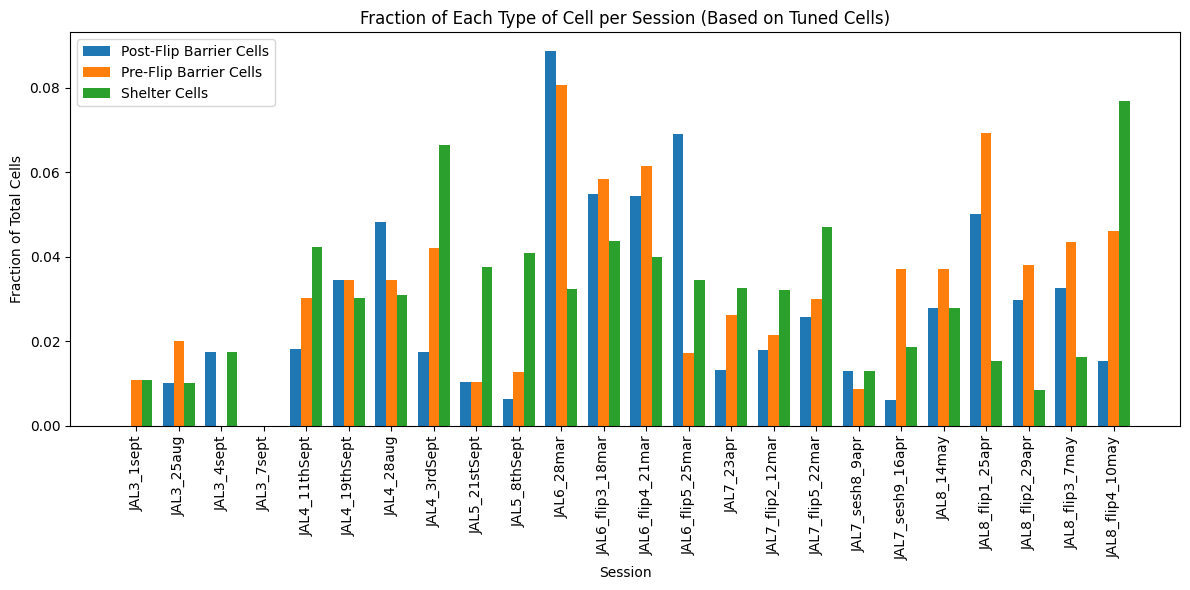

In [26]:
# Compute fractions per session based on tuned cells / total cells
fractions = {
    category: [(len(datasets[category][session]["Cell_index"]) / datasets[category][session]["total_cells"][0])
        for session in sessions
    ]
    for category in datasets
}

# Define bar width and positions
x = np.arange(len(sessions))
width = 0.25  # Bar width

# Create bar plot for computed fractions
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, fractions["post_flip_barrier_cells"], width, label="Post-Flip Barrier Cells")
ax.bar(x, fractions["pre_flip_barrier_cells"], width, label="Pre-Flip Barrier Cells")
ax.bar(x + width, fractions["shelter_cells"], width, label="Shelter Cells")

# Formatting the plot
ax.set_xlabel("Session")
ax.set_ylabel("Fraction of Total Cells")
ax.set_title("Fraction of Each Type of Cell per Session (Based on Tuned Cells)")
ax.set_xticks(x)
ax.set_xticklabels(sessions, rotation=90)  # Rotate for readability
ax.legend()

# Show plot
plt.tight_layout()
plt.show()


In [45]:
import pickle
with open(r"Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\head_direction_cells.pkl", "rb") as f:
    head_direction = pickle.load(f)
print(head_direction)

# Make the head direction the same format as the other datasets
head_direction_cells = defaultdict(lambda: defaultdict(list))

for session in head_direction:
    head_direction_cells[session]["Cell_index"] = head_direction[session]
    head_direction_cells[session]["total_cells"] = shelter_cells[session]["total_cells"]

print(head_direction_cells)
head_direction_cells["JAL6_flip3_18mar"]

defaultdict(<class 'list'>, {'JAL6_flip3_18mar': [140.0, 207.0, 212.0, 266.0, 435.0, 474.0, 546.0], 'JAL6_flip4_21mar': [150.0, 152.0, 236.0, 466.0, 467.0, 470.0, 578.0, 579.0, 610.0], 'JAL6_flip5_25mar': [347.0, 348.0, 371.0], 'JAL6_28mar': [147.0, 384.0, 467.0], 'JAL3_25aug': [], 'JAL3_1sept': [], 'JAL3_4sept': [], 'JAL3_7sept': [], 'JAL5_8thSept': [309.0, 310.0, 498.0, 618.0, 911.0], 'JAL5_21stSept': [107.0, 542.0, 757.0], 'JAL7_sesh8_9apr': [394.0, 443.0], 'JAL7_sesh9_16apr': [163.0, 164.0, 360.0, 370.0], 'JAL7_flip5_22mar': [173.0, 181.0, 182.0, 483.0, 489.0, 493.0, 599.0], 'JAL7_flip2_12mar': [279.0], 'JAL7_23apr': [261.0], 'JAL8_flip1_25apr': [423.0, 451.0], 'JAL8_flip2_29apr': [649.0], 'JAL8_flip4_10may': [], 'JAL8_14may': [], 'JAL8_flip3_7may': [], 'JAL4_3rdSept': [6.0, 11.0, 22.0, 23.0, 35.0, 45.0, 49.0, 52.0, 55.0, 58.0, 62.0, 66.0, 72.0, 79.0, 83.0, 88.0, 94.0, 101.0, 386.0, 518.0, 519.0, 524.0, 526.0, 535.0, 536.0, 629.0, 631.0, 679.0, 681.0, 704.0, 880.0, 928.0], 'JAL4_19

defaultdict(list,
            {'Cell_index': [140.0, 207.0, 212.0, 266.0, 435.0, 474.0, 546.0],
             'total_cells': [274]})

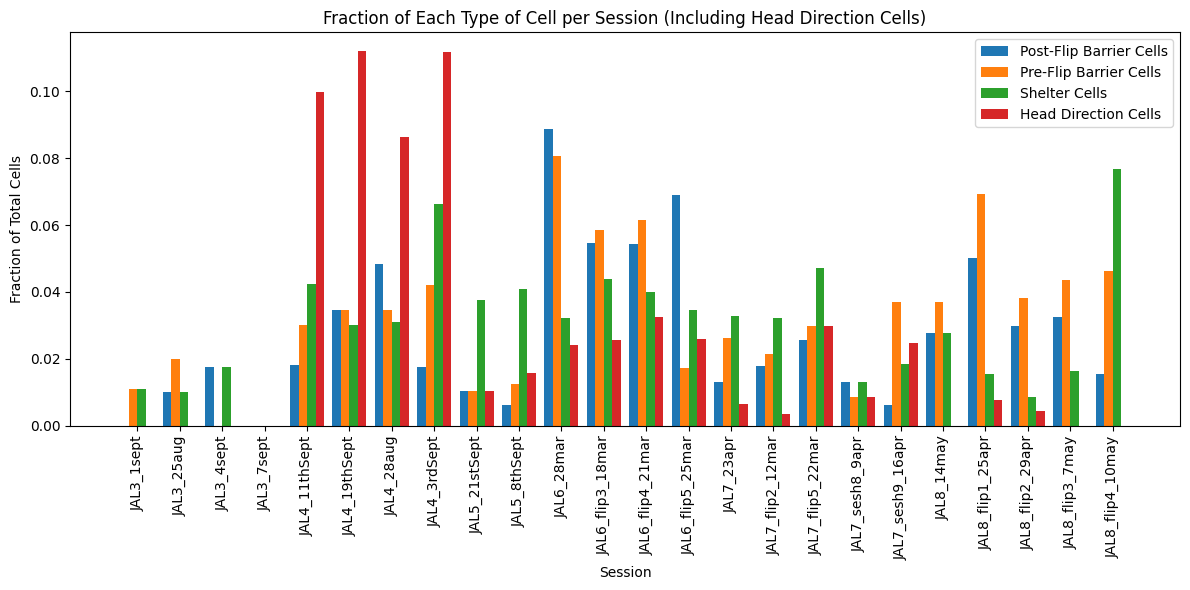

In [47]:
# Update datasets to include head_direction_cells
datasets = {
    "post_flip_barrier_cells": post_flip_barrier_cells,
    "pre_flip_barrier_cells": pre_flip_barrier_cells,
    "shelter_cells": shelter_cells,
    "head_direction_cells": head_direction_cells,  # Now correctly formatted
}

# Compute fractions per session based on tuned cells / total cells
fractions = {
    category: [
        (len(datasets[category][session]["Cell_index"]) / datasets[category][session]["total_cells"][0])
        if session in datasets[category] and "Cell_index" in datasets[category][session] and "total_cells" in datasets[category][session] and datasets[category][session]["total_cells"][0] > 0
        else 0
        for session in sessions
    ]
    for category in datasets
}

# Define bar width and positions
x = np.arange(len(sessions))
width = 0.2  # Adjusted bar width for 4 bars per session

# Create bar plot for computed fractions
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5 * width, fractions["post_flip_barrier_cells"], width, label="Post-Flip Barrier Cells")
ax.bar(x - 0.5 * width, fractions["pre_flip_barrier_cells"], width, label="Pre-Flip Barrier Cells")
ax.bar(x + 0.5 * width, fractions["shelter_cells"], width, label="Shelter Cells")
ax.bar(x + 1.5 * width, fractions["head_direction_cells"], width, label="Head Direction Cells")

# Formatting the plot
ax.set_xlabel("Session")
ax.set_ylabel("Fraction of Total Cells")
ax.set_title("Fraction of Each Type of Cell per Session (Including Head Direction Cells)")
ax.set_xticks(x)
ax.set_xticklabels(sessions, rotation=90)  # Rotate for readability
ax.legend()

# Show plot
plt.tight_layout()
plt.show()


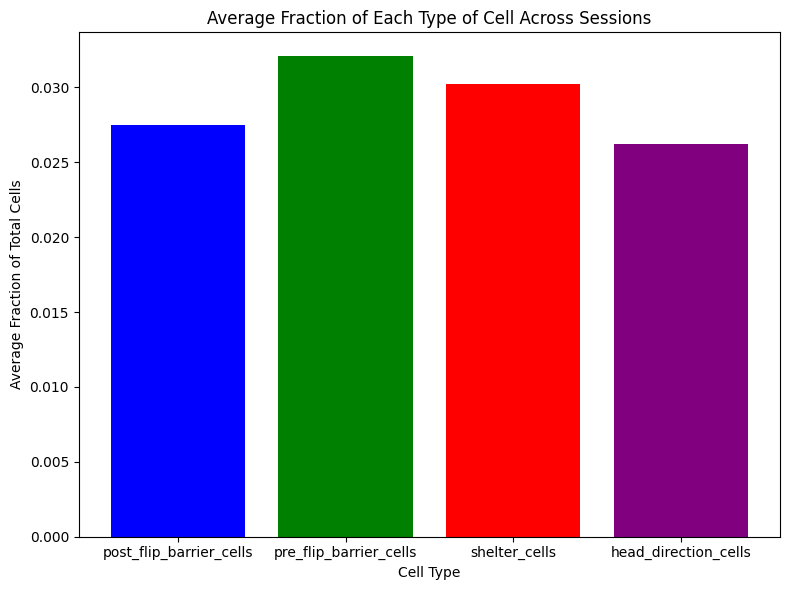

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Update datasets to include head_direction_cells
datasets = {
    "post_flip_barrier_cells": post_flip_barrier_cells,
    "pre_flip_barrier_cells": pre_flip_barrier_cells,
    "shelter_cells": shelter_cells,
    "head_direction_cells": head_direction_cells,  # Now correctly formatted
}

# Compute fractions per session based on tuned cells / total cells
fractions = {
    category: [
        (len(datasets[category][session]["Cell_index"]) / datasets[category][session]["total_cells"][0])
        if session in datasets[category] and "Cell_index" in datasets[category][session] and "total_cells" in datasets[category][session] and datasets[category][session]["total_cells"][0] > 0
        else np.nan
        for session in sessions
    ]
    for category in datasets
}

# Compute average fractions across all sessions
average_fractions = {
    category: np.nanmean(fractions[category])
    for category in datasets
}

# Create bar plot for average fractions
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(average_fractions.keys(), average_fractions.values(), color=['blue', 'green', 'red', 'purple'])

# Formatting the plot
ax.set_xlabel("Cell Type")
ax.set_ylabel("Average Fraction of Total Cells")
ax.set_title("Average Fraction of Each Type of Cell Across Sessions")

# Show plot
plt.tight_layout()
plt.show()


In [48]:
with open(r"Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\500ms_before_accuracy\500ms_before_accuracy_accuracy_ks_coeffs_data.pkl", "rb") as f:
    accuracy_ks_coeffs_data = pickle.load(f)
model_coeffs = accuracy_ks_coeffs_data["coefs"]
model_accuracy = accuracy_ks_coeffs_data["accuracy_data"]
average_coefs = {}
for session_name, folds in model_coeffs.items():
    # Stack the coefficients from all folds and compute the mean
    coefficients = np.array(list(folds.values()))  # Shape: (num_folds, num_features)
    average_coefs[session_name] = coefficients.mean(axis=0)  # Average across folds

2025-01-30 18:09:52.102 | INFO     | __main__:<module>:26 - Processing session: JAL6_flip3_18mar
2025-01-30 18:09:52.135 | INFO     | __main__:<module>:26 - Processing session: JAL6_flip4_21mar
2025-01-30 18:09:52.211 | ERROR    | __main__:<module>:19 - Excluding session: JAL6_flip5_25mar (bug in cell alignment)
2025-01-30 18:09:52.212 | INFO     | __main__:<module>:26 - Processing session: JAL6_28mar
2025-01-30 18:09:52.268 | INFO     | __main__:<module>:26 - Processing session: JAL3_25aug
2025-01-30 18:09:52.277 | INFO     | __main__:<module>:26 - Processing session: JAL3_1sept
2025-01-30 18:09:52.289 | INFO     | __main__:<module>:26 - Processing session: JAL3_4sept
2025-01-30 18:09:52.299 | INFO     | __main__:<module>:26 - Processing session: JAL3_7sept
2025-01-30 18:09:52.308 | INFO     | __main__:<module>:26 - Processing session: JAL5_8thSept
2025-01-30 18:09:52.316 | ERROR    | __main__:<module>:23 - Skipping session: JAL5_21stSept (missing coefficient data)
2025-01-30 18:09:52

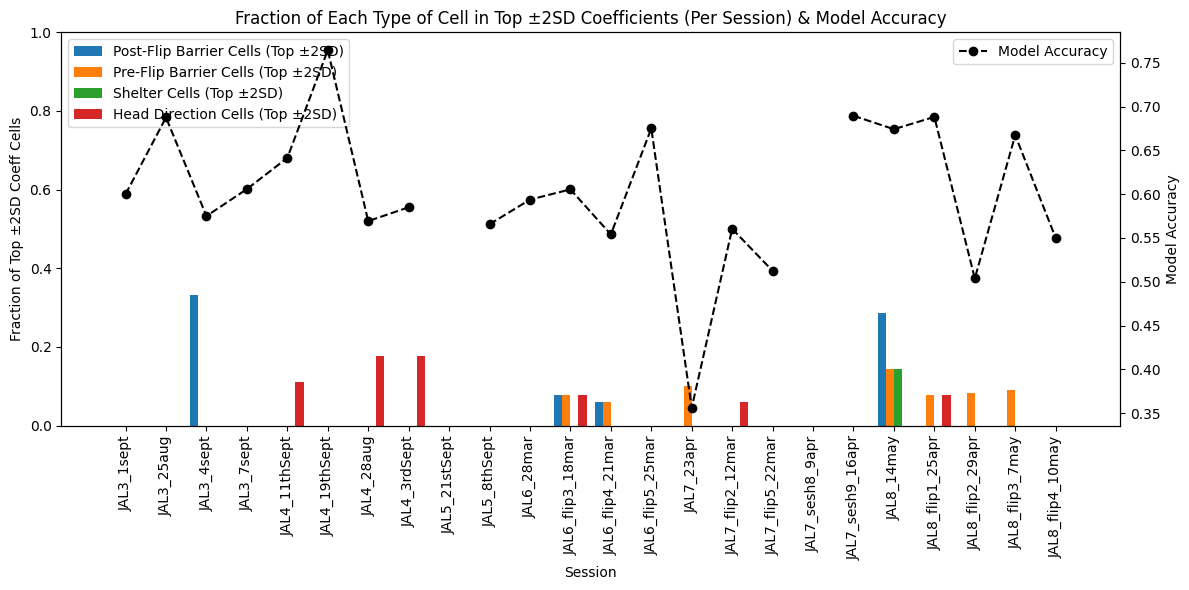

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import os

threshold = 2.0 # Define threshold: ±2 SD for significant coefficients

# Dictionary to store counts of top ±2SD cells per dataset per session
top_coeff_cells = defaultdict(lambda: defaultdict(int))
total_top_coeff_cells = defaultdict(int)

excluded_sessions = ["JAL6_flip5_25mar", "JAL8_flip4_10may", "JAL4_19thSept"]  # Excluded sessions due to mismatch

for experiment, session_name in zip(experiments_objects, session_names):
    if session_name not in model_accuracy:
        logger.warning(f"Skipping session: {session_name} (no model accuracy data)")
        continue
    if session_name in excluded_sessions:
        logger.error(f"Excluding session: {session_name} (bug in cell alignment)")
        continue
    if session_name not in average_coefs:
        logger.error(f"Skipping session: {session_name} (missing coefficient data)")
        continue
    
    logger.info(f"Processing session: {session_name}")
    
    # Load experiment data
    loaded_session = get_experiment(experiment)
    good_cluster_path = os.path.join(loaded_session.base_path, loaded_session.processed_path, "good_cluster_ids.npy")
    good_cluster_ids = np.load(good_cluster_path)
    
    # Load regression coefficients for this session
    coefs_ = average_coefs[session_name]
    
    # Identify top ±2SD coefficient indices
    coef_mean = np.mean(coefs_)
    coef_std = np.std(coefs_)
    significant_mask = (coefs_ >= coef_mean + threshold * coef_std) | (coefs_ <= coef_mean - threshold * coef_std)
    top_coeff_indices = np.where(significant_mask)[0]
    top_coeff_cells_session = good_cluster_ids[top_coeff_indices]  # Get cell IDs corresponding to top coefficients
    total_top_coeff_cells[session_name] = len(top_coeff_cells_session)
    
    # Store counts per dataset
    for category in datasets:
        dataset_cells = set(datasets[category][session_name]["Cell_index"]) if session_name in datasets[category] else set()
        intersecting_cells = np.intersect1d(top_coeff_cells_session, list(dataset_cells))
        top_coeff_cells[session_name][category] = len(intersecting_cells)

# Compute fractions per session relative to total top-coefficient cells
top_coeff_fractions = {
    category: [
        (top_coeff_cells[session][category] / total_top_coeff_cells[session])
        if session in datasets[category] and session in top_coeff_cells and total_top_coeff_cells[session] > 0
        else 0
        for session in sessions
    ]
    for category in datasets
}

# Extract model accuracies, ensuring numerical values only
accuracies = [model_accuracy[session] if session in model_accuracy and isinstance(model_accuracy[session], (int, float)) else np.nan for session in sessions]

# Define bar width and positions
x = np.arange(len(sessions))
width = 0.2  # Adjusted bar width for 4 bars per session

# Create bar plot for computed fractions of top ±2SD coefficient cells
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(x - 1.5 * width, top_coeff_fractions["post_flip_barrier_cells"], width, label="Post-Flip Barrier Cells (Top ±2SD)")
ax1.bar(x - 0.5 * width, top_coeff_fractions["pre_flip_barrier_cells"], width, label="Pre-Flip Barrier Cells (Top ±2SD)")
ax1.bar(x + 0.5 * width, top_coeff_fractions["shelter_cells"], width, label="Shelter Cells (Top ±2SD)")
ax1.bar(x + 1.5 * width, top_coeff_fractions["head_direction_cells"], width, label="Head Direction Cells (Top ±2SD)")

# Formatting the primary y-axis (fractions)
ax1.set_xlabel("Session")
ax1.set_ylabel("Fraction of Top ±2SD Coeff Cells")
ax1.set_title("Fraction of Each Type of Cell in Top ±2SD Coefficients (Per Session) & Model Accuracy")
ax1.set_xticks(x)
ax1.set_xticklabels(sessions, rotation=90)  # Rotate for readability
ax1.set_ylim(0, 1)  # Ensure fractions are within 0-1 range
ax1.legend(loc="upper left")

# Create secondary y-axis for accuracy
twin_ax = ax1.twinx()
twin_ax.set_ylabel("Model Accuracy")
twin_ax.plot(x, accuracies, color='black', linestyle='--', marker='o', label='Model Accuracy')
twin_ax.legend(loc="upper right")

# Show plot
plt.tight_layout()
plt.show()



2025-01-30 18:19:57.681 | INFO     | __main__:<module>:26 - Processing session: JAL6_flip3_18mar
2025-01-30 18:19:57.689 | INFO     | __main__:<module>:26 - Processing session: JAL6_flip4_21mar
2025-01-30 18:19:57.698 | ERROR    | __main__:<module>:19 - Excluding session: JAL6_flip5_25mar (bug in cell alignment)
2025-01-30 18:19:57.699 | INFO     | __main__:<module>:26 - Processing session: JAL6_28mar
2025-01-30 18:19:57.707 | INFO     | __main__:<module>:26 - Processing session: JAL3_25aug
2025-01-30 18:19:57.716 | INFO     | __main__:<module>:26 - Processing session: JAL3_1sept
2025-01-30 18:19:57.724 | INFO     | __main__:<module>:26 - Processing session: JAL3_4sept
2025-01-30 18:19:57.732 | INFO     | __main__:<module>:26 - Processing session: JAL3_7sept
2025-01-30 18:19:57.742 | INFO     | __main__:<module>:26 - Processing session: JAL5_8thSept
2025-01-30 18:19:57.750 | ERROR    | __main__:<module>:23 - Skipping session: JAL5_21stSept (missing coefficient data)
2025-01-30 18:19:57

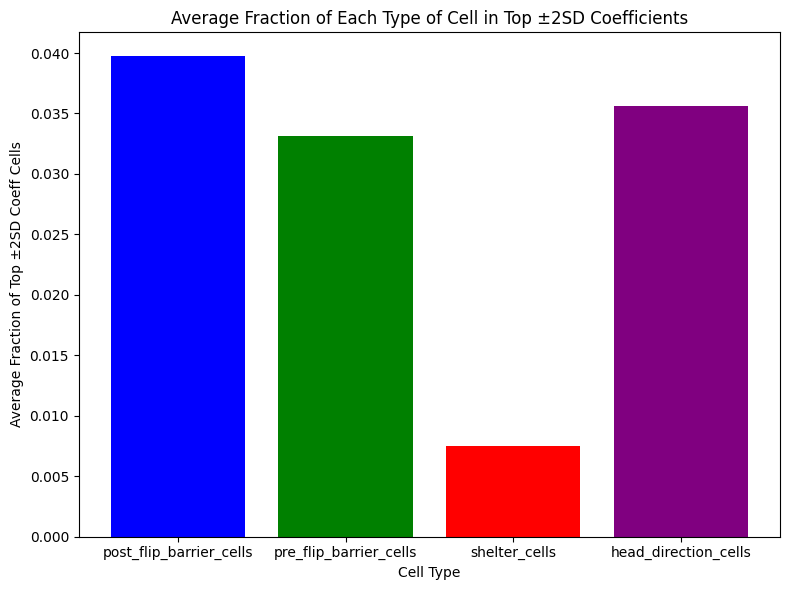

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Define threshold: ±2 SD for significant coefficients
threshold = 2.0

# Dictionary to store counts of top ±2SD cells per dataset per session
top_coeff_cells = defaultdict(lambda: defaultdict(int))
total_top_coeff_cells = defaultdict(int)

excluded_sessions = ["JAL6_flip5_25mar", "JAL8_flip4_10may", "JAL4_19thSept"]  # Excluded sessions due to mismatch

for experiment, session_name in zip(experiments_objects, session_names):
    if session_name not in model_accuracy:
        logger.warning(f"Skipping session: {session_name} (no model accuracy data)")
        continue
    if session_name in excluded_sessions:
        logger.error(f"Excluding session: {session_name} (bug in cell alignment)")
        continue
    
    if session_name not in average_coefs:
        logger.error(f"Skipping session: {session_name} (missing coefficient data)")
        continue
    
    logger.info(f"Processing session: {session_name}")
    
    # Load experiment data
    loaded_session = get_experiment(experiment)
    good_cluster_path = os.path.join(loaded_session.base_path, loaded_session.processed_path, "good_cluster_ids.npy")
    good_cluster_ids = np.load(good_cluster_path)
    
    # Load regression coefficients for this session
    coefs_ = average_coefs[session_name]
    
    # Identify top ±2SD coefficient indices
    coef_mean = np.mean(coefs_)
    coef_std = np.std(coefs_)
    significant_mask = (coefs_ >= coef_mean + threshold * coef_std) | (coefs_ <= coef_mean - threshold * coef_std)
    
    top_coeff_indices = np.where(significant_mask)[0]
    top_coeff_cells_session = good_cluster_ids[top_coeff_indices]  # Get cell IDs corresponding to top coefficients
    total_top_coeff_cells[session_name] = len(top_coeff_cells_session)
    
    # Store counts per dataset
    for category in datasets:
        dataset_cells = set(datasets[category][session_name]["Cell_index"]) if session_name in datasets[category] else set()
        intersecting_cells = np.intersect1d(top_coeff_cells_session, list(dataset_cells))
        
        top_coeff_cells[session_name][category] = len(intersecting_cells)

# Compute average fractions across all sessions
average_top_coeff_fractions = {
    category: np.nanmean([
        (top_coeff_cells[session][category] / total_top_coeff_cells[session])
        if session in datasets[category] and session in top_coeff_cells and total_top_coeff_cells[session] > 0
        else np.nan
        for session in sessions
    ])
    for category in datasets
}

# Create bar plot for average fractions
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(average_top_coeff_fractions.keys(), average_top_coeff_fractions.values(), color=['blue', 'green', 'red', 'purple'])

# Formatting the plot
ax.set_xlabel("Cell Type")
ax.set_ylabel("Average Fraction of Top ±2SD Coeff Cells")
ax.set_title("Average Fraction of Each Type of Cell in Top ±2SD Coefficients")

# Show plot
plt.tight_layout()
plt.show()


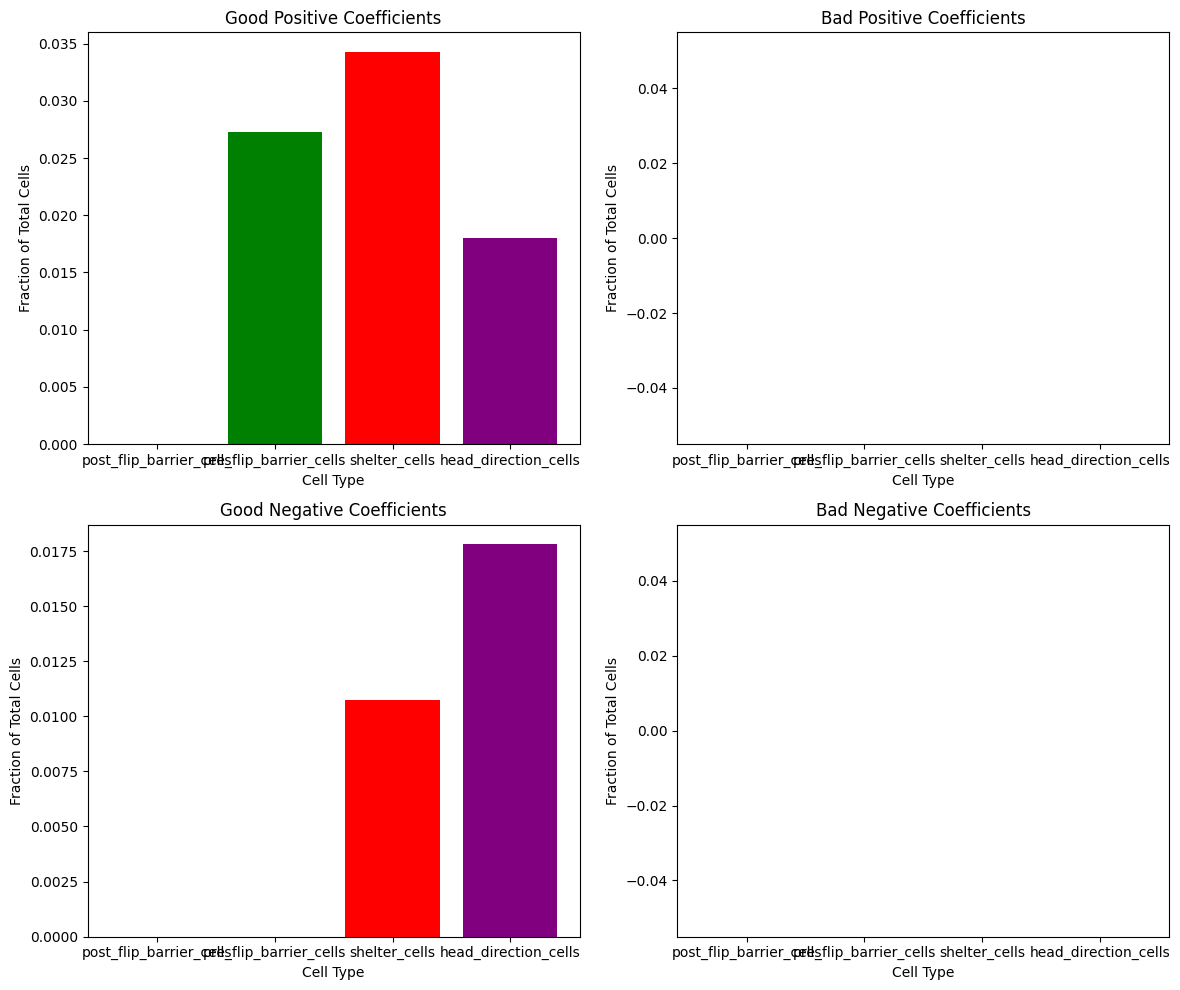

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Update datasets to include head_direction_cells
datasets = {
    "post_flip_barrier_cells": post_flip_barrier_cells,
    "pre_flip_barrier_cells": pre_flip_barrier_cells,
    "shelter_cells": shelter_cells,
    "head_direction_cells": head_direction_cells,  # Now correctly formatted
}

# Define coefficient categories
good_positive = defaultdict(lambda: defaultdict(int))
bad_positive = defaultdict(lambda: defaultdict(int))
good_negative = defaultdict(lambda: defaultdict(int))
bad_negative = defaultdict(lambda: defaultdict(int))

good_positive_total = defaultdict(int)
bad_positive_total = defaultdict(int)
good_negative_total = defaultdict(int)
bad_negative_total = defaultdict(int)

for experiment, session_name in zip(experiments_objects, session_names):
    if session_name not in average_coefs:
        continue
    
    coefs_ = average_coefs[session_name]
    coef_mean = np.mean(coefs_)
    coef_std = np.std(coefs_)
    
    positive_mask = coefs_ >= coef_mean + 2 * coef_std
    negative_mask = coefs_ <= coef_mean - 2 * coef_std
    
    good_positive_indices = np.where(positive_mask & (model_accuracy.get(session_name, 0) > 0.5))[0]
    bad_positive_indices = np.where(positive_mask & (model_accuracy.get(session_name, 0) <= 0.5))[0]
    good_negative_indices = np.where(negative_mask & (model_accuracy.get(session_name, 0) > 0.5))[0]
    bad_negative_indices = np.where(negative_mask & (model_accuracy.get(session_name, 0) <= 0.5))[0]
    
    for category in datasets:
        session_cells = set(datasets[category][session_name]["Cell_index"]) if session_name in datasets[category] else set()
        
        good_positive[session_name][category] = len(np.intersect1d(good_positive_indices, list(session_cells)))
        bad_positive[session_name][category] = len(np.intersect1d(bad_positive_indices, list(session_cells)))
        good_negative[session_name][category] = len(np.intersect1d(good_negative_indices, list(session_cells)))
        bad_negative[session_name][category] = len(np.intersect1d(bad_negative_indices, list(session_cells)))
        
    good_positive_total[session_name] = max(len(good_positive_indices), 1)
    bad_positive_total[session_name] = max(len(bad_positive_indices), 1)
    good_negative_total[session_name] = max(len(good_negative_indices), 1)
    bad_negative_total[session_name] = max(len(bad_negative_indices), 1)

# Compute average fractions per coefficient category
fraction_categories = {
    "Good Positive": good_positive,
    "Bad Positive": bad_positive,
    "Good Negative": good_negative,
    "Bad Negative": bad_negative,
}

global_fractions = {}
for category, total_dict in zip(fraction_categories.keys(), [good_positive_total, bad_positive_total, good_negative_total, bad_negative_total]):
    global_fractions[category] = {}
    for cell_type in datasets:
        fractions = [
            (fraction_categories[category][session][cell_type] / total_dict[session])
            if session in fraction_categories[category] and cell_type in fraction_categories[category][session] and total_dict[session] > 0
            else np.nan
            for session in sessions
        ]
        global_fractions[category][cell_type] = np.nanmean(fractions)

# Plot four separate bar graphs
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
categories = list(global_fractions.keys())
colors = ['blue', 'green', 'red', 'purple']

for i, ax in enumerate(axes.flat):
    ax.bar(global_fractions[categories[i]].keys(), global_fractions[categories[i]].values(), color=colors)
    ax.set_xlabel("Cell Type")
    ax.set_ylabel("Fraction of Total Cells")
    ax.set_title(f"{categories[i]} Coefficients")

plt.tight_layout()
plt.show()